# Project on Bank Account management Dataset

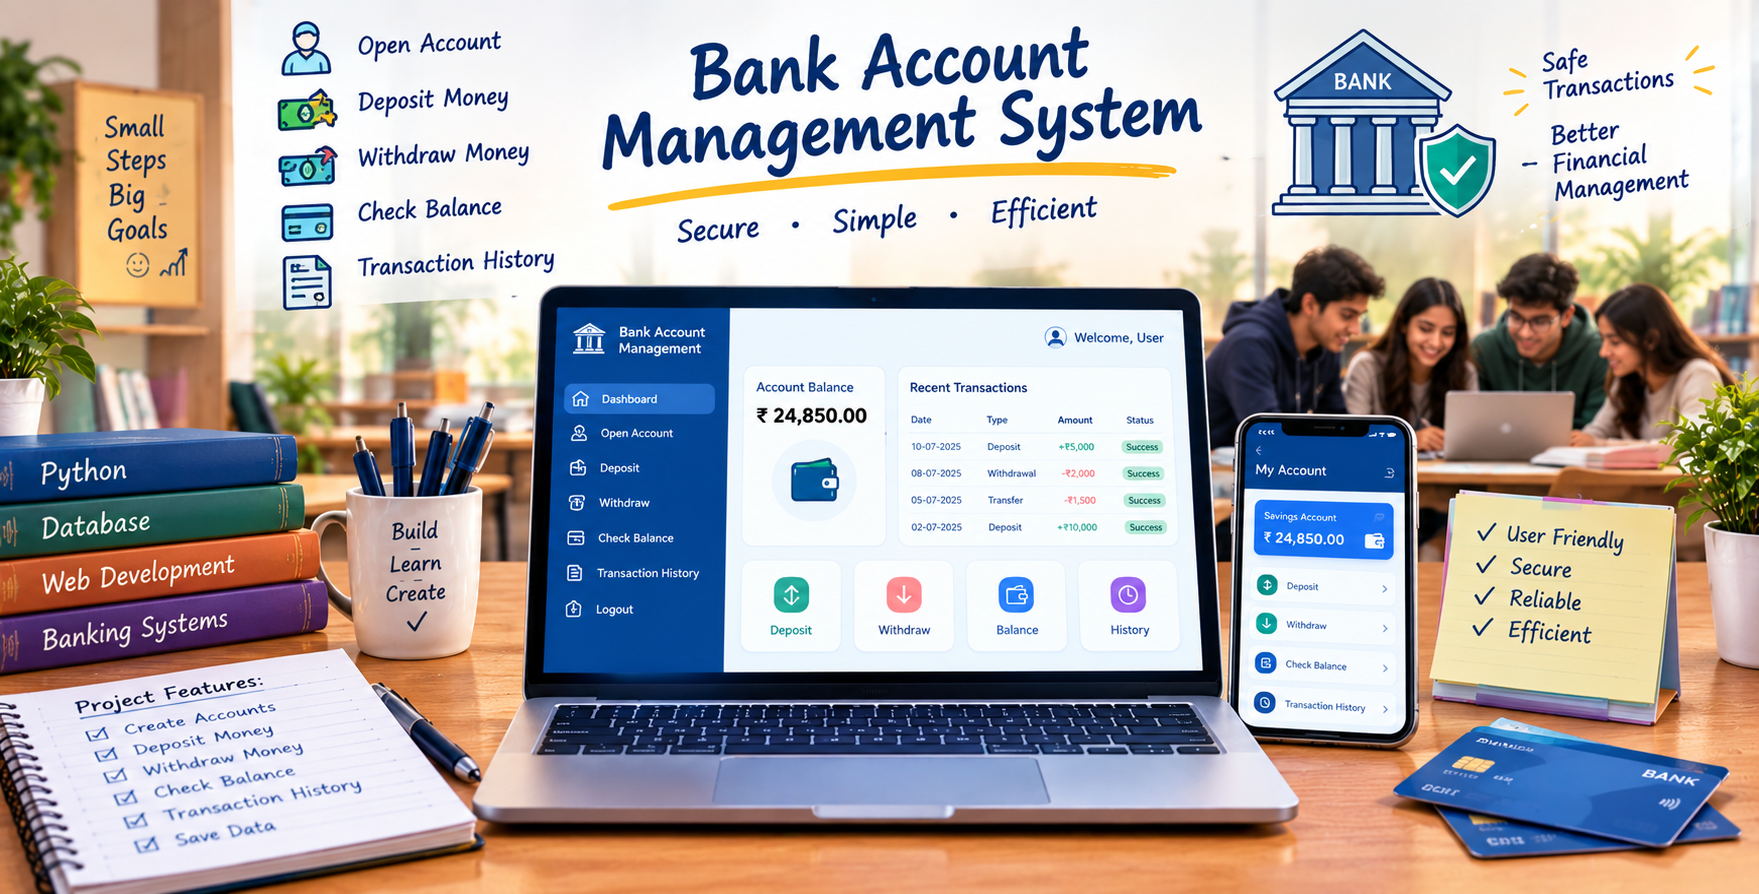

In [23]:
from IPython.display import Image
Image(filename= r"C:\Users\Priyanka\Downloads\Bank Account Management Workspace (1).png")

# Data Overview

### A bank want to wants to know the transaction information about an account holder in their bank. For that they have given data which is as follow:
* Account Number
* Date, transaction details and value date.
* CHQ no., withdrawl amount, deposit amounnt and balance amount    

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [4]:
DATA_PATH = r"C:\Users\Priyanka\Downloads\bank.csv"
df = pd.read_csv(DATA_PATH)
df

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1.000000e+06,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2.000000e+06,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2.500000e+06,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5.500000e+06,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6.000000e+06,.
...,...,...,...,...,...,...,...,...,...
116196,409000362497',2019-03-05,TRF TO 1196428 Indiaforensic SE,NaN,2019-03-05,117934.30,NaN,-1.901902e+09,.
116197,409000362497',2019-03-05,FDRL/INTERNAL FUND TRANSFE,NaN,2019-03-05,NaN,300000.0,-1.901602e+09,.
116198,409000362497',2019-03-05,FDRL/INTERNAL FUND TRANSFE,NaN,2019-03-05,NaN,300000.0,-1.901302e+09,.
116199,409000362497',2019-03-05,IMPS 05-03-20194C,NaN,2019-03-05,109868.65,NaN,-1.901412e+09,.


In [5]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


In [6]:
df.shape

(116201, 9)

# Contents of data

In [7]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 116201 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Account No           116201 non-null  str    
 1   DATE                 116201 non-null  str    
 2   TRANSACTION DETAILS  113702 non-null  str    
 3   CHQ.NO.              905 non-null     float64
 4   VALUE DATE           116201 non-null  str    
 5   WITHDRAWAL AMT       53549 non-null   float64
 6   DEPOSIT AMT          62652 non-null   float64
 7   BALANCE AMT          116201 non-null  float64
 8   .                    116201 non-null  str    
dtypes: float64(4), str(5)
memory usage: 14.2 MB


In [8]:
df.isna().sum()

Account No                  0
DATE                        0
TRANSACTION DETAILS      2499
CHQ.NO.                115296
VALUE DATE                  0
WITHDRAWAL AMT          62652
DEPOSIT AMT             53549
BALANCE AMT                 0
.                           0
dtype: int64

In [9]:
df.columns

Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='str')

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CHQ.NO.,905.0,7.916145e+05,1.512059e+05,1.000000e+00,7.042310e+05,8.738120e+05,8.741670e+05,8.745250e+05
WITHDRAWAL AMT,53549.0,4.489190e+06,1.084850e+07,1.000000e-02,3.000000e+03,4.708300e+04,5.000000e+06,4.594475e+08
DEPOSIT AMT,62652.0,3.806586e+06,8.683093e+06,1.000000e-02,9.900000e+04,4.265000e+05,4.746411e+06,5.448000e+08
BALANCE AMT,116201.0,-1.404852e+09,5.348202e+08,-2.045201e+09,-1.690383e+09,-1.661395e+09,-1.236888e+09,8.500000e+06


# Data information and preprocessing

## Creating an Account

In [13]:
accounts = []
def create_account(acc_no, initial_balance=0.0):
    account = {'Account No': acc_no,'BALANCE AMT': initial_balance}
    accounts.append(account)
    print(f"Account {acc_no} created with balance {initial_balance}")
create_account("ACC001", 1000)
create_account("ACC002", 500)


Account ACC001 created with balance 1000
Account ACC002 created with balance 500


### Deposit money into an account

In [16]:
def deposit(acc_no, amount):
    for acc in accounts:
        if acc['Account No'] == acc_no:
            acc['BALANCE AMT'] += amount
            print(f"Deposited {amount} into {acc_no}. New balance: {acc['BALANCE AMT']}")
            return
    print("Account not found.")
deposit("ACC001", 500)    



Deposited 500 into ACC001. New balance: 1500


### Withdraw money from account

In [18]:
def withdraw(acc_no, amount):
    for acc in accounts:
        if acc['Account No'] == acc_no:
            if acc['BALANCE AMT'] >= amount:
                acc['BALANCE AMT'] -= amount
                print(f"Withdrew {amount} from {acc_no}. New balance: {acc['BALANCE AMT']}")
            else:
                print("Insufficient balance.")
            return
    print("Account not found.")
withdraw("ACC001", 300)

Withdrew 300 from ACC001. New balance: 1200


### Check balance

In [19]:
def check_balance(acc_no):
    for acc in accounts:
        if acc['Account No'] == acc_no:
            print(f"Balance for {acc_no}: {acc['BALANCE AMT']}")
            return acc['BALANCE AMT']
    print("Account not found.")
    return None

check_balance("ACC001")    


Balance for ACC001: 1200


1200

### Maintain transaction history

In [20]:
transactions = []

def log_transaction(acc_no, trans_type, amount, balance):
    transactions.append({'Account No': acc_no,'Type': trans_type,'Amount': amount,'Balance After': balance })
def show_history(acc_no):
    history = [t for t in transactions if t['Account No'] == acc_no]
    if history:
        print(f"Transaction history for {acc_no}:")
        for t in history:
            print(t)
    else:
        print("No transactions found for this account.")
show_history("ACC001")

No transactions found for this account.


### Fuction to save account

In [21]:
import csv

def save_accounts(filename="accounts.csv"):
    if accounts:   
        with open(filename, "w", newline="") as file:
            writer = csv.DictWriter(file, fieldnames=['Account No', 'BALANCE AMT'])
            writer.writeheader()
            writer.writerows(accounts)
        print("Accounts saved.")
    else:
        print("No accounts to save.")
save_accounts()

Accounts saved.


### Function to save transaction

In [22]:
def save_transactions(filename="transactions.csv"):
    if transactions:
        with open(filename, "w", newline="") as file:
            writer = csv.DictWriter(file, fieldnames=['Account No', 'Type', 'Amount', 'Balance After'])
            writer.writeheader()
            writer.writerows(transactions)
        print("Transactions saved.")
    else:
        print("No transactions to save.")
save_transactions()

No transactions to save.


# Reference

##### kaggle:https://www.kaggle.com/datasets/apoorvwatsky/bank-transaction-data